In [3]:
from PIL import Image
import numpy as np
import glob

In [34]:
widthRatio = []
heightRatio = []

for file in sorted(glob.glob("../Data/Face/Aiden/*.jpg")):
    img = np.array(Image.open(file), dtype=np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

for file in sorted(glob.glob("../Data/Face/Andrew/*.jpg")):
    img = np.array(Image.open(file), dtype=np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

for file in sorted(glob.glob("../Data/Face/Cathy/*.jpg")):
    img = np.array(Image.open(file), dtype=np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

In [27]:
print('너비 평균 해상도 :', np.mean(widthRatio))
print('높이 평균 해상도 :', np.mean(heightRatio))

너비 평균 해상도 : 277.7962962962963
높이 평균 해상도 : 330.35185185185185


In [66]:
i = 1
for file in sorted(glob.glob("../Data/Face/Aiden/*.jpg")):
    img = Image.open(file)
    imgResize = img.resize((278, 330), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f"../Data/AidenNew/image_{i:02}.jpg", "JPEG")
    i+=1

In [73]:
i = 1
for file in sorted(glob.glob("../Data/Face/Andrew/*.jpg")):
    img = Image.open(file)
    imgResize = img.resize((278, 330), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f"../Data/AndrewNew/image_{i:02}.jpg", "JPEG")
    i+=1

In [74]:
i = 1
for file in sorted(glob.glob("../Data/Face/Cathy/*.jpg")):
    img = Image.open(file)
    imgResize = img.resize((278, 330), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f"../Data/CathyNew/image_{i:02}.jpg", "JPEG")
    i+=1

In [67]:
number_of_data = 18
img_width_size = 278
img_height_size = 330

In [68]:
AidenData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype=np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)
AidenData.shape

(18, 330, 278)

In [69]:
i=0
for file in sorted(glob.glob("../Data/AidenNew/*.jpg")):
    img = np.array(Image.open(file), dtype=np.int32)
    AidenData[i,:,:] = img
    i+=1
AidenData.shape

(18, 330, 278)

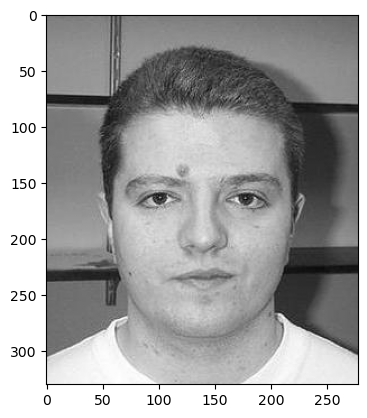

In [ ]:
# 이미지 확인하기
import matplotlib.pyplot as plt

plt.imshow(AidenData[0], cmap='gray')
plt.show()

In [75]:
AndrewData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype=np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)
AndrewData.shape

(18, 330, 278)

In [76]:
i=0
for file in sorted(glob.glob("../Data/AndrewNew/*.jpg")):
    img = np.array(Image.open(file), dtype=np.int32)
    AndrewData[i,:,:] = img
    i+=1
AndrewData.shape

(18, 330, 278)

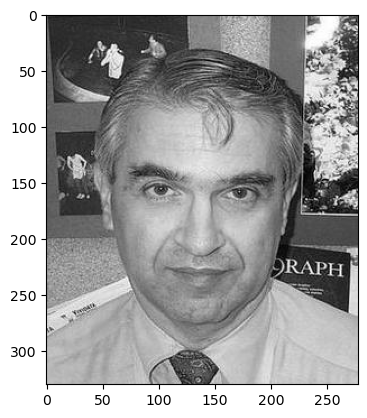

In [77]:
# 이미지 확인하기
import matplotlib.pyplot as plt

plt.imshow(AndrewData[0], cmap='gray')
plt.show()

In [78]:
CathyData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype=np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)
CathyData.shape

(18, 330, 278)

In [79]:
i=0
for file in sorted(glob.glob("../Data/CathyNew/*.jpg")):
    img = np.array(Image.open(file), dtype=np.int32)
    CathyData[i,:,:] = img
    i+=1
CathyData.shape

(18, 330, 278)

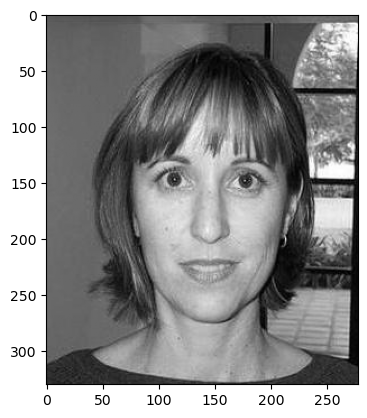

In [80]:
# 이미지 확인하기
import matplotlib.pyplot as plt

plt.imshow(CathyData[0], cmap='gray')
plt.show()

In [81]:
train = np.concatenate(
    [AidenData, AndrewData, CathyData]
)
train.shape

(54, 330, 278)

In [82]:
target = np.concatenate(
    [np.zeros(27), np.ones(27)]
)
target.shape

(54,)

In [83]:
train = train.reshape(-1, img_height_size, img_width_size, 1) / 255.0
train.shape

(54, 330, 278, 1)

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
# Train과 Test 분리
trainData, testData, trainTarget, testTarget = \
    train_test_split(   
        train,
        target,
        test_size = 0.2,    
        random_state=42
    )

In [86]:
print(trainData.shape)
print(testData.shape)
print(trainTarget.shape)
print(testTarget.shape)

(43, 330, 278, 1)
(11, 330, 278, 1)
(43,)
(11,)


In [88]:
from tensorflow import keras
from tensorflow.keras.layers import Input

In [118]:
# -------------------------------------------------------------
# 1. CNN 모델 구성 (합성곱 신경망)
# -------------------------------------------------------------
model = keras.Sequential()
model.add(Input(shape=(img_height_size, img_width_size, 1)))

keras.layers.RandomFlip("horizontal"),       # 좌우 반전 (얼굴 이미지는 좌우 반전해도 얼굴이니까요!)
keras.layers.RandomRotation(0.1),            # ±10도 이내로 살짝 회전
keras.layers.RandomZoom(0.1),                # ±10% 이내로 살짝 확대/축소


model.add(
    keras.layers.Conv2D(
        32,
        kernel_size=3,
        activation='relu',
        padding='same'
    )
)

model.add(keras.layers.BatchNormalization()) # 과적합 방지 및 학습 속도 향상

model.add(keras.layers.MaxPooling2D(2))

model.add(
    keras.layers.Conv2D(
        64,
        kernel_size=3,
        activation='relu',
        padding='same'
    )
)
model.add(keras.layers.BatchNormalization()) # 과적합 방지 및 학습 속도 향상
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.3))

model.add(
    keras.layers.Dense(
        3,
        activation='softmax', # 다중분류
    )
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 330, 278, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 330, 278, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 165, 139, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 165, 139, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 165, 139, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 82, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 362112)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │    46,350,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,370,051 (176.89 MB)

 Trainable params: 46,369,859 (176.89 MB)

 Non-trainable params: 192 (768.00 B)

In [119]:
# -------------------------------------------------------------
# 2. 모델 컴파일
# -------------------------------------------------------------
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_cnn_face_model.keras")

early_stopping_cb= keras.callbacks.EarlyStopping(
                    patience=5,
                    restore_best_weights=True                  
)

In [120]:
# -------------------------------------------------------------
# 3. 모델 학습 (validation 데이터 활용)
# -------------------------------------------------------------
history = model.fit(
    trainData, 
    trainTarget, 
    epochs=100,                
    validation_data=(testData, testTarget),
    callbacks = [checkpoint_cb,early_stopping_cb],
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step - accuracy: 0.3953 - loss: 33.9125 - val_accuracy: 0.5455 - val_loss: 3.0163
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.8837 - loss: 43.9424 - val_accuracy: 0.5455 - val_loss: 1.8132
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.8605 - loss: 14.5346 - val_accuracy: 0.3636 - val_loss: 2.0718
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.9767 - loss: 0.5264 - val_accuracy: 0.7273 - val_loss: 0.8236
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5455 - val_loss: 2.0661
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5455 - val_loss: 4.0376
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.9767 - loss: 0.7726 - val_accuracy: 0.5455 - val_loss: 6.4293
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.9535 - loss: 7.5864 - val_accuracy: 0.5455 - val_loss: 10.

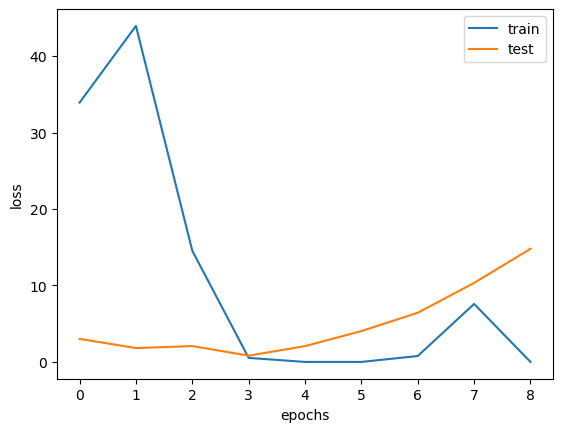

In [121]:
# 시각화 해보기
history.history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'test'])
plt.show()

In [122]:
# 평가
model.evaluate(trainData, trainTarget)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.8372 - loss: 0.3360


[0.33598870038986206, 0.8372092843055725]

In [123]:
model.evaluate(testData, testTarget)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.7273 - loss: 0.8236


[0.8235843777656555, 0.7272727489471436]